# DistilBERT Fine-tuning — GitHub Repository Maturity Classifier

**Runtime:** GPU (Runtime → Change runtime type → T4 GPU)  
**Input:** `train.csv`, `val.csv`, `test.csv` from Google Drive  
**Output:** fine-tuned model, confusion matrix, evaluation metrics JSON

## 1. Mount Google Drive & Install Packages

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install transformers datasets scikit-learn torch -q

## 2. Imports

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    get_linear_schedule_with_warmup,
)

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4


## 3. Configuration

Edit `DRIVE_DATA_PATH` to match where you uploaded the `splits/` folder in your Drive.

In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────
DRIVE_ROOT       = '/content/drive/MyDrive/github_hiring_data'
DRIVE_DATA_PATH = "/content/drive/MyDrive/github_hiring_intelligence/"
MODEL_SAVE_PATH  = f'{DRIVE_ROOT}/models/trained_models'
FIGURES_PATH     = f'{DRIVE_ROOT}/output/figures'
METRICS_PATH     = f'{DRIVE_ROOT}/output/metrics'

# ── Hyperparameters ────────────────────────────────────────────────────────
MODEL_NAME   = 'distilbert-base-uncased'
MAX_LEN      = 256
BATCH_SIZE   = 16
NUM_EPOCHS   = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
WARMUP_FRAC   = 0.1   # fraction of total steps used for warmup
GRAD_CLIP     = 1.0
SEED          = 42

# ── Label schema ───────────────────────────────────────────────────────────
LABEL_NAMES = ['intern', 'junior', 'senior', 'lead', 'template', 'low_value']
LABEL2ID    = {l: i for i, l in enumerate(LABEL_NAMES)}
ID2LABEL    = {i: l for i, l in enumerate(LABEL_NAMES)}
NUM_LABELS  = len(LABEL_NAMES)

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 4. Load Data

In [6]:
train_df = pd.read_csv(f'{DRIVE_DATA_PATH}/train.csv')
val_df   = pd.read_csv(f'{DRIVE_DATA_PATH}/val.csv')
test_df  = pd.read_csv(f'{DRIVE_DATA_PATH}/test.csv')

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    before = len(df)
    df.dropna(subset=['label', 'text_summary'], inplace=True)
    df = df[df['label'].isin(LABEL_NAMES)].reset_index(drop=True)
    print(f"{name:<6}  {len(df):>4} rows  (dropped {before - len(df)} invalid)")

# Re-assign after in-place mutation
train_df = pd.read_csv(f'{DRIVE_DATA_PATH}/train.csv').dropna(subset=['label','text_summary'])
train_df = train_df[train_df['label'].isin(LABEL_NAMES)].reset_index(drop=True)
val_df   = pd.read_csv(f'{DRIVE_DATA_PATH}/val.csv').dropna(subset=['label','text_summary'])
val_df   = val_df[val_df['label'].isin(LABEL_NAMES)].reset_index(drop=True)
test_df  = pd.read_csv(f'{DRIVE_DATA_PATH}/test.csv').dropna(subset=['label','text_summary'])
test_df  = test_df[test_df['label'].isin(LABEL_NAMES)].reset_index(drop=True)

print("\nTrain label distribution:")
print(train_df['label'].value_counts().to_string())

train    559 rows  (dropped 0 invalid)
val      120 rows  (dropped 0 invalid)
test     121 rows  (dropped 0 invalid)

Train label distribution:
label
junior       178
senior       177
intern       143
lead          48
template      10
low_value      3


## 5. Encode Labels & Compute Class Weights

In [7]:
for df in (train_df, val_df, test_df):
    df['label_id'] = df['label'].map(LABEL2ID)

# Balanced class weights to counter junior/senior dominance
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=train_df['label_id'].values,
)
class_weights = torch.tensor(raw_weights, dtype=torch.float).to(DEVICE)

print("Class weights (higher = rarer class):")
for label, w in zip(LABEL_NAMES, raw_weights):
    bar = '█' * int(w * 10)
    print(f"  {label:<12}  {w:.3f}  {bar}")

Class weights (higher = rarer class):
  intern        0.652  ██████
  junior        0.523  █████
  senior        0.526  █████
  lead          1.941  ███████████████████
  template      9.317  █████████████████████████████████████████████████████████████████████████████████████████████
  low_value     31.056  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████


## 6. Dataset Class & DataLoaders

In [8]:
class RepoDataset(Dataset):
    """Tokenises text_summary strings and returns (input_ids, mask, label)."""

    def __init__(self, texts: list[str], labels: list[int],
                 tokenizer: DistilBertTokenizer, max_len: int):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [9]:
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

train_dataset = RepoDataset(train_df['text_summary'].tolist(),
                            train_df['label_id'].tolist(), tokenizer, MAX_LEN)
val_dataset   = RepoDataset(val_df['text_summary'].tolist(),
                            val_df['label_id'].tolist(),   tokenizer, MAX_LEN)
test_dataset  = RepoDataset(test_df['text_summary'].tolist(),
                            test_df['label_id'].tolist(),  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Batches — train: 35  val: 8  test: 8


## 7. Model, Optimizer & Scheduler

In [10]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)

optimizer    = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps  = len(train_loader) * NUM_EPOCHS
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * WARMUP_FRAC),
    num_training_steps=total_steps,
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
print(f"Total training steps: {total_steps}  (warmup: {int(total_steps * WARMUP_FRAC)})")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 66,958,086
Total training steps: 105  (warmup: 10)


## 8. Training Loop

In [11]:
def evaluate(model, loader):
    """Returns (avg_loss, accuracy, weighted_f1, predictions, true_labels)."""
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            logits = model(input_ids=input_ids,
                           attention_mask=attention_mask).logits
            total_loss += loss_fn(logits, labels).item()

            all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels

In [12]:
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for step, batch in enumerate(train_loader, start=1):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids,
                       attention_mask=attention_mask).logits
        loss   = loss_fn(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        if step % 10 == 0 or step == len(train_loader):
            print(f"  Epoch {epoch}/{NUM_EPOCHS}  step {step:>3}/{len(train_loader)}"
                  f"  batch_loss={loss.item():.4f}", end='\r')

    avg_train = running_loss / len(train_loader)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"  train_loss : {avg_train:.4f}")
    print(f"  val_loss   : {val_loss:.4f}")
    print(f"  val_acc    : {val_acc:.4f}")
    print(f"  val_f1     : {val_f1:.4f}\n")

print("Training complete.")


Epoch 1/3
  train_loss : 1.7273
  val_loss   : 1.8581
  val_acc    : 0.3167
  val_f1     : 0.1523


Epoch 2/3
  train_loss : 1.6951
  val_loss   : 1.7640
  val_acc    : 0.5833
  val_f1     : 0.5497


Epoch 3/3
  train_loss : 1.5519
  val_loss   : 1.6997
  val_acc    : 0.6250
  val_f1     : 0.5846

Training complete.


### Training curves

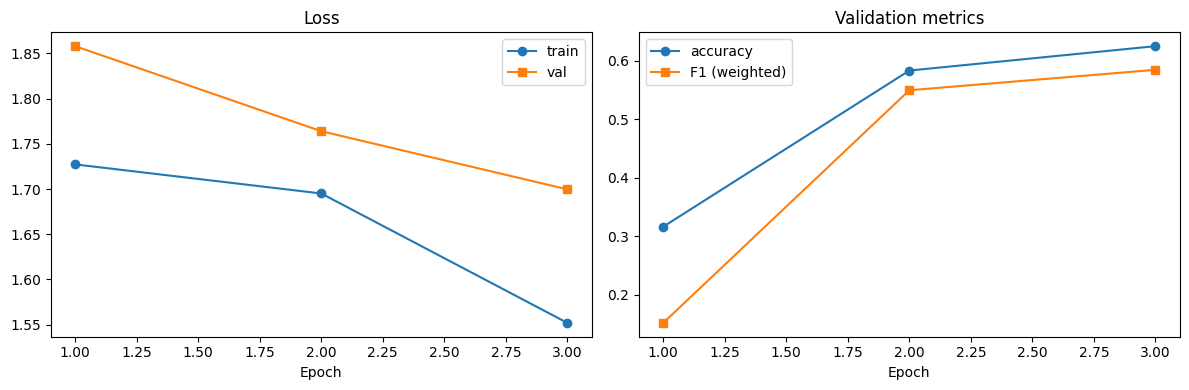

In [13]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], 'o-', label='train')
axes[0].plot(epochs, history['val_loss'],   's-', label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['val_acc'], 'o-', label='accuracy')
axes[1].plot(epochs, history['val_f1'],  's-', label='F1 (weighted)')
axes[1].set_title('Validation metrics')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Test Set Evaluation

In [14]:
_, test_acc, test_f1_w, test_preds, test_labels = evaluate(model, test_loader)

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"Accuracy          : {test_acc:.4f}")
print(f"F1 (weighted)     : {test_f1_w:.4f}")
print(f"Precision (weighted): {precision_score(test_labels, test_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall (weighted) : {recall_score(test_labels, test_preds, average='weighted', zero_division=0):.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=LABEL_NAMES,
    digits=4,
    zero_division=0,
))

TEST SET EVALUATION
Accuracy          : 0.5950
F1 (weighted)     : 0.5436
Precision (weighted): 0.5808
Recall (weighted) : 0.5950

              precision    recall  f1-score   support

      intern     0.5085    0.9677    0.6667        31
      junior     0.7778    0.3590    0.4912        39
      senior     0.6364    0.7368    0.6829        38
        lead     0.0000    0.0000    0.0000        10
    template     0.0000    0.0000    0.0000         2
   low_value     0.0000    0.0000    0.0000         1

    accuracy                         0.5950       121
   macro avg     0.3204    0.3439    0.3068       121
weighted avg     0.5808    0.5950    0.5436       121



## 10. Confusion Matrix

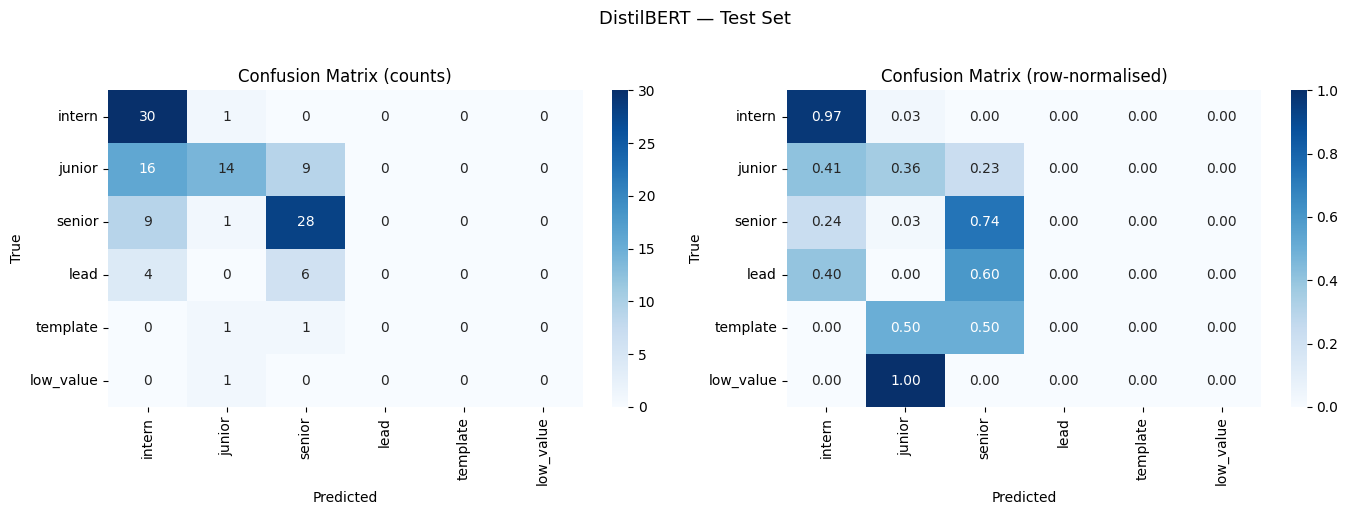

Saved -> /content/drive/MyDrive/github_hiring_data/output/figures/confusion_matrix.png


In [15]:
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Row-normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalised)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('DistilBERT — Test Set', fontsize=13, y=1.02)
plt.tight_layout()

Path(FIGURES_PATH).mkdir(parents=True, exist_ok=True)
fig.savefig(f'{FIGURES_PATH}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FIGURES_PATH}/confusion_matrix.png")

## 11. Save Model

In [16]:
Path(MODEL_SAVE_PATH).mkdir(parents=True, exist_ok=True)
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)
print(f"Model + tokenizer saved -> {MODEL_SAVE_PATH}")
print("Files written:")
for p in Path(MODEL_SAVE_PATH).iterdir():
    print(f"  {p.name}  ({p.stat().st_size / 1024:.0f} KB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + tokenizer saved -> /content/drive/MyDrive/github_hiring_data/models/trained_models
Files written:
  config.json  (1 KB)
  model.safetensors  (261567 KB)
  tokenizer_config.json  (0 KB)
  tokenizer.json  (695 KB)


## 12. Save Evaluation Metrics

In [17]:
prec_per  = precision_score(test_labels, test_preds, average=None,
                            labels=list(range(NUM_LABELS)), zero_division=0)
rec_per   = recall_score(test_labels, test_preds,    average=None,
                         labels=list(range(NUM_LABELS)), zero_division=0)
f1_per    = f1_score(test_labels, test_preds,        average=None,
                     labels=list(range(NUM_LABELS)), zero_division=0)

metrics = {
    "model": MODEL_NAME,
    "hyperparameters": {
        "epochs":        NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size":    BATCH_SIZE,
        "max_len":       MAX_LEN,
        "weight_decay":  WEIGHT_DECAY,
    },
    "overall": {
        "accuracy":           round(test_acc, 4),
        "f1_weighted":        round(float(test_f1_w), 4),
        "precision_weighted": round(float(precision_score(
            test_labels, test_preds, average='weighted', zero_division=0)), 4),
        "recall_weighted":    round(float(recall_score(
            test_labels, test_preds, average='weighted', zero_division=0)), 4),
    },
    "per_class": {
        label: {
            "precision": round(float(prec_per[i]), 4),
            "recall":    round(float(rec_per[i]),  4),
            "f1":        round(float(f1_per[i]),   4),
            "support":   int((np.array(test_labels) == i).sum()),
        }
        for i, label in enumerate(LABEL_NAMES)
    },
    "training_history": {
        "train_loss": [round(v, 4) for v in history['train_loss']],
        "val_loss":   [round(v, 4) for v in history['val_loss']],
        "val_acc":    [round(v, 4) for v in history['val_acc']],
        "val_f1":     [round(v, 4) for v in history['val_f1']],
    },
}

Path(METRICS_PATH).mkdir(parents=True, exist_ok=True)
out_path = f'{METRICS_PATH}/evaluation_results.json'
with open(out_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved -> {out_path}")
print(json.dumps(metrics['overall'], indent=2))

Metrics saved -> /content/drive/MyDrive/github_hiring_data/output/metrics/evaluation_results.json
{
  "accuracy": 0.595,
  "f1_weighted": 0.5436,
  "precision_weighted": 0.5808,
  "recall_weighted": 0.595
}
